In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
latent_dim = 2
epochs = 20


In [ ]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

test_data = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 400)
        self.fc2 = nn.Linear(400, 784)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        return torch.sigmoid(self.fc2(h))


encoder = Encoder().to(device)
decoder = Decoder().to(device)


### Without KL Divergence

In [ ]:
def ae_loss(recon, x):
    return nn.functional.binary_cross_entropy(recon, x, reduction="sum")


In [ ]:
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

for epoch in range(epochs):
    encoder.train()
    decoder.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        mu, _ = encoder(x)
        z = mu
        recon = decoder(z)

        loss = ae_loss(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[AE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")


[AE] Epoch 1, Loss: 179.4125
[AE] Epoch 2, Loss: 159.6259
[AE] Epoch 3, Loss: 154.7774
[AE] Epoch 4, Loss: 152.1048
[AE] Epoch 5, Loss: 150.1629
[AE] Epoch 6, Loss: 148.6549
[AE] Epoch 7, Loss: 147.3198
[AE] Epoch 8, Loss: 146.2272
[AE] Epoch 9, Loss: 145.3026
[AE] Epoch 10, Loss: 144.4678
[AE] Epoch 11, Loss: 143.7871
[AE] Epoch 12, Loss: 143.1091
[AE] Epoch 13, Loss: 142.5952
[AE] Epoch 14, Loss: 142.0446
[AE] Epoch 15, Loss: 141.6350
[AE] Epoch 16, Loss: 141.1966
[AE] Epoch 17, Loss: 140.8116
[AE] Epoch 18, Loss: 140.5276
[AE] Epoch 19, Loss: 140.1227
[AE] Epoch 20, Loss: 139.8164


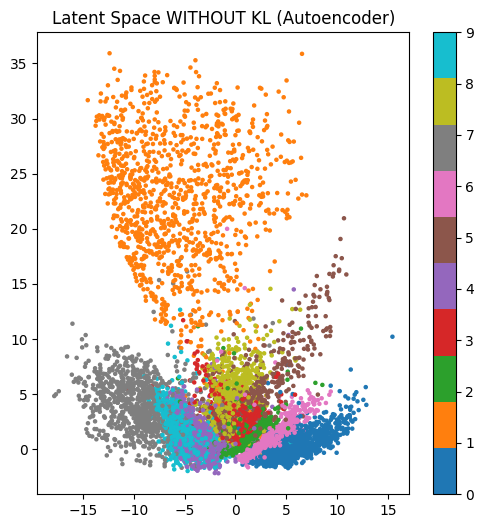

In [ ]:
latents, labels = [], []

encoder.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        mu, _ = encoder(x)
        latents.append(mu.cpu())
        labels.append(y)

latents = torch.cat(latents)
labels = torch.cat(labels)

plt.figure(figsize=(6,6))
plt.scatter(latents[:,0], latents[:,1], c=labels, cmap="tab10", s=5)
plt.title("Latent Space WITHOUT KL (Autoencoder)")
plt.colorbar()
plt.show()


### With KL

In [ ]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [ ]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


In [ ]:
encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)


In [ ]:
for epoch in range(epochs):
    encoder.train()
    decoder.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        recon = decoder(z)

        loss = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[VAE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")


[VAE] Epoch 1, Loss: 189.1389
[VAE] Epoch 2, Loss: 167.5817
[VAE] Epoch 3, Loss: 163.4852
[VAE] Epoch 4, Loss: 161.2839
[VAE] Epoch 5, Loss: 159.7754
[VAE] Epoch 6, Loss: 158.5724
[VAE] Epoch 7, Loss: 157.5833
[VAE] Epoch 8, Loss: 156.6543
[VAE] Epoch 9, Loss: 155.7919
[VAE] Epoch 10, Loss: 155.0769
[VAE] Epoch 11, Loss: 154.3925
[VAE] Epoch 12, Loss: 153.7652
[VAE] Epoch 13, Loss: 153.2832
[VAE] Epoch 14, Loss: 152.7212
[VAE] Epoch 15, Loss: 152.2675
[VAE] Epoch 16, Loss: 151.8836
[VAE] Epoch 17, Loss: 151.5419
[VAE] Epoch 18, Loss: 151.1577
[VAE] Epoch 19, Loss: 150.8599
[VAE] Epoch 20, Loss: 150.5500


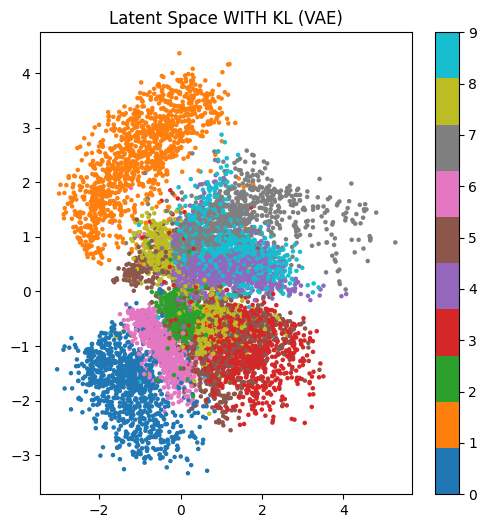

In [ ]:
latents, labels = [], []

encoder.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        mu, _ = encoder(x)
        latents.append(mu.cpu())
        labels.append(y)

latents = torch.cat(latents)
labels = torch.cat(labels)

plt.figure(figsize=(6,6))
plt.scatter(latents[:,0], latents[:,1], c=labels, cmap="tab10", s=5)
plt.title("Latent Space WITH KL (VAE)")
plt.colorbar()
plt.show()
